In [48]:
# Data manipulation
import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Encoding
from sklearn.preprocessing import LabelEncoder

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay,
    precision_score,
    recall_score,
    f1_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Load processed dataset
from pandas import set_option


data = pd.read_csv(r"C:\Datascience_Projects\Fraud_Detection_Project\data\nova_pay_eda_ready.csv")
set_option("display.max_columns", None) 
# Preview
data.head()

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,transaction_hour,log_amount_usd,log_fee,log_exchange_rate
0,2022-10-03 18:40:59.468549+00:00,us,usd,cad,atm,278.19,278.19,4.25,1.351351,False,us,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0,18,5.631893,1.658228,0.854990
1,2022-10-03 20:39:38.468549+00:00,ca,cad,mxn,web,208.51,154.29,4.24,12.758621,True,ca,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0,20,5.045294,1.656321,2.621666
2,2022-10-03 23:02:43.468549+00:00,us,usd,cny,mobile,160.33,160.33,2.70,7.142857,False,us,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0,23,5.083452,1.308333,2.097141
3,2022-10-04 01:08:53.468549+00:00,us,usd,eur,mobile,59.41,59.41,2.22,0.925926,False,us,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0,1,4.101155,1.169381,0.655407
4,2022-10-04 09:35:03.468549+00:00,us,usd,inr,mobile,200.96,200.96,3.61,83.333333,False,us,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0,9,5.308070,1.528228,4.434777


# Define Target Variable

In [50]:
# Target variable
target = "is_fraud"

In [51]:
# Preview timestamp and extracted transaction hour

print(
    data[["timestamp", "transaction_hour"]].head(10)
)

                          timestamp  transaction_hour
0  2022-10-03 18:40:59.468549+00:00                18
1  2022-10-03 20:39:38.468549+00:00                20
2  2022-10-03 23:02:43.468549+00:00                23
3  2022-10-04 01:08:53.468549+00:00                 1
4  2022-10-04 09:35:03.468549+00:00                 9
5  2022-10-04 12:09:59.468549+00:00                12
6  2022-10-04 12:37:41.468549+00:00                12
7  2022-10-04 16:27:44.468549+00:00                16
8  2022-10-04 21:00:36.468549+00:00                21
9  2022-10-04 21:20:42.468549+00:00                21


In [ ]:
# ==========================================
# Chronological data Split
# ==========================================

data = data.sort_values('timestamp').reset_index(drop=True)
data = data.drop(columns=['timestamp'])

# Convert boolean columns to int so they're captured as numerical features
# (otherwise they're neither 'object' nor 'int64'/'float64' and get silently
# dropped by the ColumnTransformer's default remainder='drop')
bool_cols = data.select_dtypes(include=['bool']).columns
data[bool_cols] = data[bool_cols].astype(int)

categorical_cols = data.select_dtypes(include=['object']).columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).drop(columns=['is_fraud']).columns

split_index = int(len(data) * 0.8)
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

X_train = train_data.drop(columns=['is_fraud'])
y_train = train_data['is_fraud']
X_test = test_data.drop(columns=['is_fraud'])
y_test = test_data['is_fraud']

In [53]:
# ==========================================
# Encoding and Standardization
# ==========================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Fill missing ip_country with the row's home_country (keeps the column all-string)
X_train["ip_country"] = X_train["ip_country"].fillna(X_train["home_country"])
X_test["ip_country"] = X_test["ip_country"].fillna(X_test["home_country"])

# Clean infinities/NaNs only in numeric columns — don't touch categorical dtypes
X_train[numerical_cols] = X_train[numerical_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
X_test[numerical_cols] = X_test[numerical_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [54]:
# Check remaining data types

print(X_train.dtypes)

home_country                  object
source_currency               object
dest_currency                 object
channel                       object
amount_src                   float64
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
new_device                      bool
ip_country                    object
location_mismatch               bool
ip_risk_score                float64
kyc_tier                      object
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
transaction_hour               int64
log_amount_usd               float64
log_fee                      float64
log_exchange_rate            float64
dtype: object


In [55]:
# Check for object columns

print(
    X_train.select_dtypes(include="object").columns
)

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'ip_country', 'kyc_tier'],
      dtype='object')


## Train Logistic Regression Model

In [58]:
# Initialize model
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

# Train model
log_model.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [59]:
# Predict classes
y_pred = log_model.predict(X_test_processed)

# Predict probabilities
y_prob = log_model.predict_proba(X_test_processed)[:,1]

## Evaluate Model (Log. Reg)

In [60]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("  ")
print("Logistic Regression Classification Report:")
print("  ")
print(classification_report(y_test, y_pred))

Accuracy: 0.9569120287253142
  
Logistic Regression Classification Report:
  
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      2010
           1       0.73      0.90      0.80       218

    accuracy                           0.96      2228
   macro avg       0.86      0.93      0.89      2228
weighted avg       0.96      0.96      0.96      2228



## Confusion Matrix (Log.  Reg)

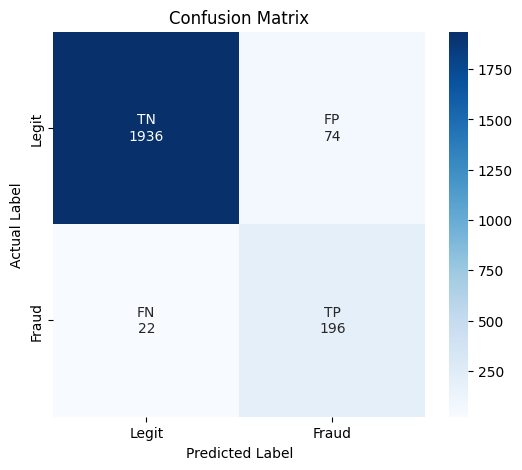

In [62]:

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create labels
labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

# Combine labels with values
annot_labels = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot_labels[i, j] = (
            labels[i, j] + "\n" + str(cm[i, j])
        )

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Legit", "Fraud"],
    yticklabels=["Legit", "Fraud"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## ROC Curve

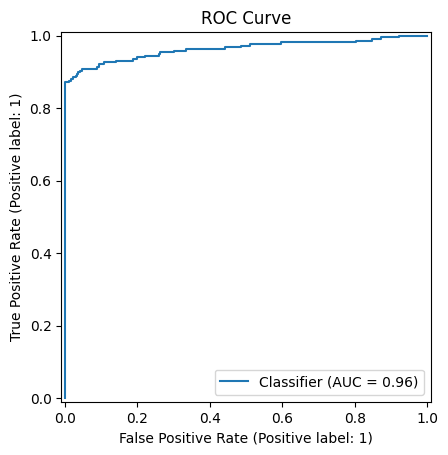

In [63]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")

plt.show()

# Initialize XGBoost Model (Advanced Model)

In [64]:
# Initialize XGBoost classifier

from xgboost import XGBClassifier


xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [65]:
# Train XGBoost model

xgb_model.fit(
    X_train_processed,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [66]:
# Predict fraud classes

y_pred_xgb = xgb_model.predict(X_test_processed)

# Predict fraud probabilities

y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:,1]

## Evaluate Model Performance

In [67]:
accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

print("XGBoost Accuracy:", accuracy_xgb)
print("  ")
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

XGBoost Accuracy: 0.9847396768402155
  
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2010
           1       0.97      0.87      0.92       218

    accuracy                           0.98      2228
   macro avg       0.98      0.93      0.95      2228
weighted avg       0.98      0.98      0.98      2228



## Generate confusion matrix

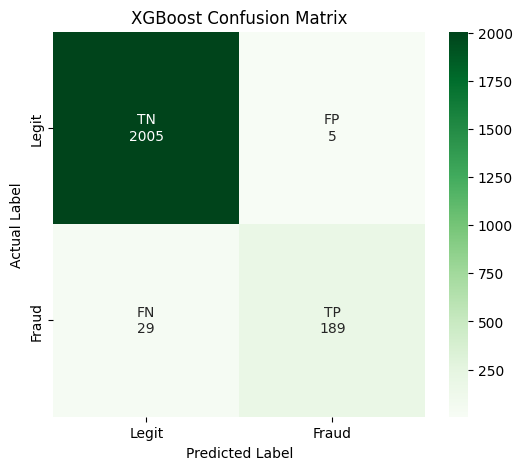

In [69]:
# Generate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

# Labels
labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

# Combine labels with values

annot_labels = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        annot_labels[i, j] = (
            labels[i, j]
            + "\n"
            + str(cm[i, j])
        )

# Plot confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Greens",
    xticklabels=["Legit", "Fraud"],
    yticklabels=["Legit", "Fraud"]
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## ROC-AUC Score & ROC Curve

XGBoost ROC-AUC: 0.9505408736135834


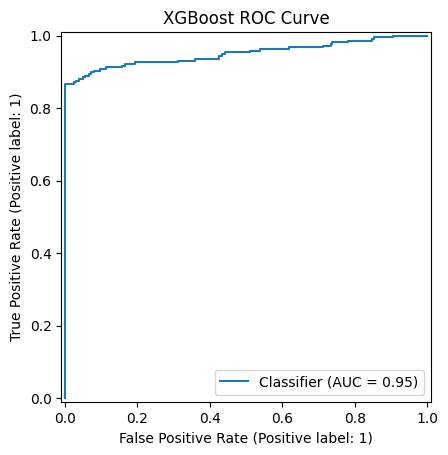

In [70]:
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost ROC-AUC:", roc_auc_xgb)


RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title("XGBoost ROC Curve")

plt.show()

## Feature Importance

In [ ]:

feature_importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": xgb_model.feature_importances_
})

# Sort values

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features

print(feature_importance.head(10))

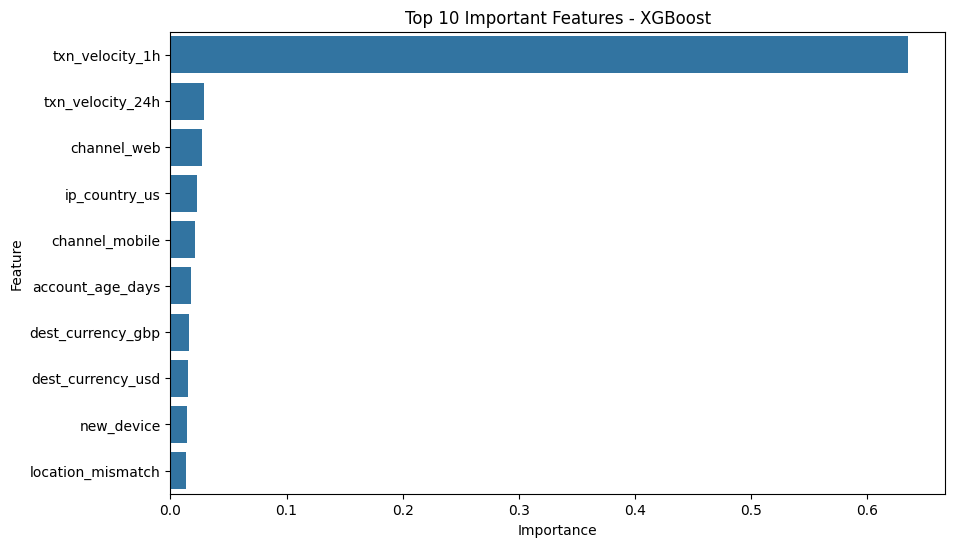

In [24]:
# Visualize top features

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Important Features - XGBoost")

plt.show()

# Hyperparameter Tuning for XGBoost

In [ ]:

from sklearn.model_selection import RandomizedSearchCV

# Calculate imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    tree_method="hist"
)

param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "gamma": [0, 0.05, 0.1, 0.2],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10],
    "scale_pos_weight": [
        1,
        scale_pos_weight,
        scale_pos_weight * 0.75,
        scale_pos_weight * 1.25
    ]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=75,
    scoring="f1",   # better balance than recall only
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_processed, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest F1 Score:")
print(random_search.best_score_)


In [ ]:
# =========================================
# Evaluate Tuned XGBoost Model
# =========================================

best_xgb = random_search.best_estimator_

# Predictions
y_pred_tuned = best_xgb.predict(X_test_processed)
y_prob_tuned = best_xgb.predict_proba(X_test_processed)[:, 1]

# Classification report
print("Tuned XGBoost Classification Report:")
print(classification_report(y_test, y_pred_tuned))

# ROC-AUC
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("Tuned XGBoost ROC-AUC:", roc_auc_tuned)
print("Tuned XGBoost Confusion Matrix:")
print(cm_tuned)

# Build tuned labels from the tuned confusion matrix
annot_labels_tuned = np.empty_like(cm_tuned).astype(str)

for i in range(cm_tuned.shape[0]):
    for j in range(cm_tuned.shape[1]):
        annot_labels_tuned[i, j] = (
            labels[i, j]
            + "\n"
            + str(cm_tuned[i, j])
        )

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_tuned,
    annot=annot_labels_tuned,
    fmt="",
    cmap="Greens"
)
plt.title("Tuned XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


# Compare Model Performance (Log. Reg (Baseline), XGBoost, Tuned XGBoost)

In [27]:
# =========================================
# Import Evaluation Metrics
# =========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================================
# Logistic Regression Metrics
# =========================================

accuracy_log = accuracy_score(y_test, y_pred)
precision_log = precision_score(y_test, y_pred)
recall_log = recall_score(y_test, y_pred)
f1_log = f1_score(y_test, y_pred)
roc_auc_log = roc_auc_score(y_test, y_prob)

# =========================================
# XGBoost Metrics
# =========================================

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# =========================================
# Tuned XGBoost Metrics
# =========================================

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

In [28]:
# Create model comparison table

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "XGBoost",
        "Tuned XGBoost"
    ],

    "Accuracy": [
        accuracy_log,
        accuracy_xgb,
        accuracy_tuned
    ],

    "Precision": [
        precision_log,
        precision_xgb,
        precision_tuned
    ],

    "Recall": [
        recall_log,
        recall_xgb,
        recall_tuned
    ],

    "F1-Score": [
        f1_log,
        f1_xgb,
        f1_tuned
    ],

    "ROC-AUC": [
        roc_auc_log,
        roc_auc_xgb,
        roc_auc_tuned
    ]
})

print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.953321   0.705036  0.899083  0.790323  0.963757
1              XGBoost  0.983842   0.964286  0.866972  0.913043  0.960224
2        Tuned XGBoost  0.986984   1.000000  0.866972  0.928747  0.969758


<Figure size 1000x600 with 0 Axes>

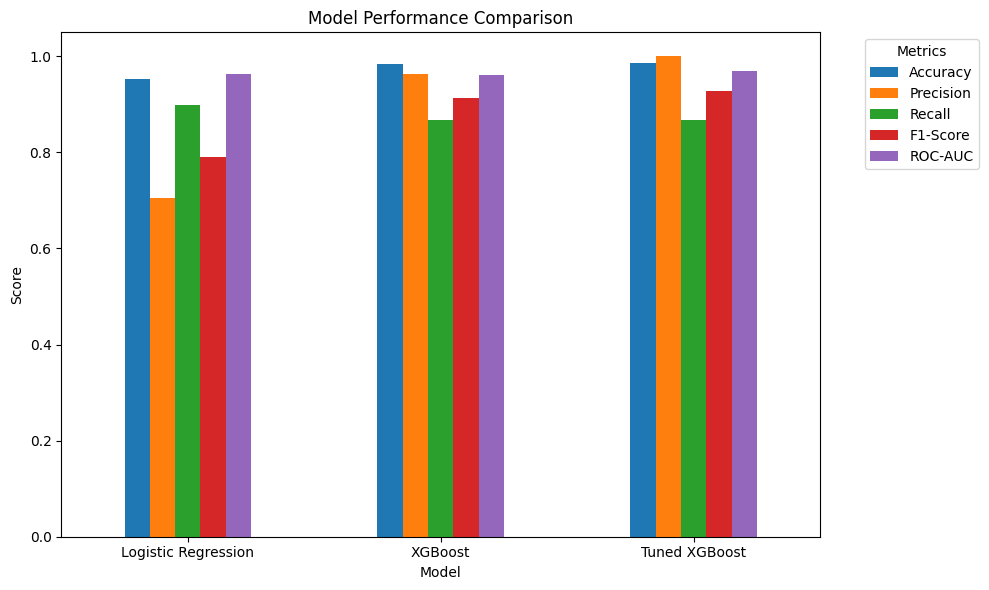

In [29]:
# Visualize model performance comparison

comparison_plot = comparison_df.set_index("Model")

plt.figure(figsize=(10,6))

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

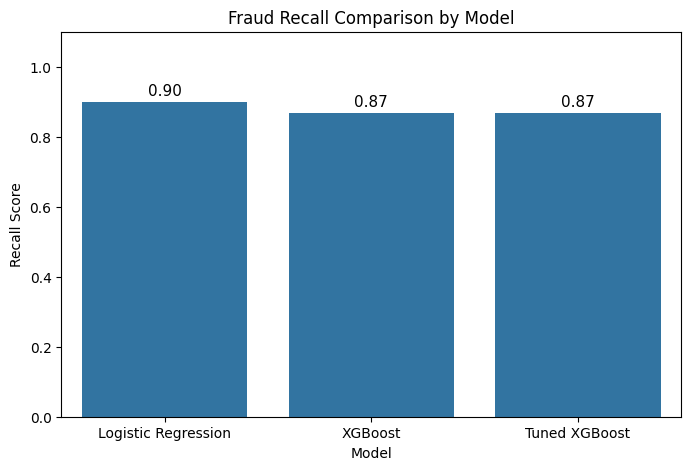

In [30]:
# Visualize recall comparison only

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="Model",
    y="Recall",
    data=comparison_df
)

# Add recall values on top of bars
for i, value in enumerate(comparison_df["Recall"]):
    ax.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontsize=11
    )

plt.title("Fraud Recall Comparison by Model")
plt.xlabel("Model")
plt.ylabel("Recall Score")
plt.ylim(0, 1.1)

plt.show()

In [ ]:
# ==========================================
# Get predicted probabilities
# ==========================================

# All three models were trained on the ColumnTransformer's processed output
y_prob_log = log_model.predict_proba(X_test_processed)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]
y_prob_tuned = best_xgb.predict_proba(X_test_processed)[:, 1]

# ==========================================
# Calculate ROC curves
# ==========================================

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Tuned XGBoost
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)
auc_tuned = roc_auc_score(y_test, y_prob_tuned)

# ==================================
# Plot ROC Curves
# ==================================

plt.figure(figsize=(10, 7))

# Logistic Regression ROC
plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
 )

# XGBoost ROC
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.3f})"
 )

# Tuned XGBoost ROC
plt.plot(
    fpr_tuned,
    tpr_tuned,
    label=f"Tuned XGBoost (AUC = {auc_tuned:.3f})"
 )

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle="--")

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Fraud Detection Models")

# Legend
plt.legend()

# Show plot
plt.show()

# SHAP Explainability for XGBoost

In [32]:
# Import SHAP
import shap
import matplotlib.pyplot as plt

c:\Datascience_Projects\Fraud_Detection_Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Use the tuned XGBoost model (best performing, trained on the preprocessor's output)
model_to_explain = best_xgb

# Wrap the processed test features in a DataFrame with real column names,
# since X_test_processed is a raw (possibly sparse) array from the ColumnTransformer
X_test_processed_dense = (
    X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed
)
X_test_processed_df = pd.DataFrame(
    X_test_processed_dense,
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

# Create SHAP explainer
explainer = shap.TreeExplainer(model_to_explain)

# Calculate SHAP values on the same processed feature space the model was trained on
shap_values = explainer.shap_values(X_test_processed_df)

## SHAP Feature Importance

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_processed_df,
    plot_type="bar"
)

## SHAP Summary Plot

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_processed_df
)

# Explain  Transaction (Sampling two transactions)

In [ ]:
# Select first transaction (row index = 0  )
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test_processed_df.iloc[sample_index],
        feature_names=X_test_processed_df.columns
    )
)

In [ ]:
# Select another transaction (row index = 10  )
sample_index = 10

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test_processed_df.iloc[sample_index],
        feature_names=X_test_processed_df.columns
    )
)

In [ ]:
# Export the final tuned XGBoost model artifact for production use
from pathlib import Path
import joblib

artifact_dir = Path(r"C:\Datascience_Projects\Fraud_Detection_Project\artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

# Feature importance for the actual exported model (best_xgb), using the
# preprocessor's real output feature names (matches what best_xgb was trained on)
tuned_feature_importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

tuned_top_features = tuned_feature_importance.head(10)

model_bundle = {
    "model": best_xgb,
    "preprocessor": preprocessor,
    "feature_columns": list(preprocessor.get_feature_names_out()),
    "comparison_df": comparison_df,
    "feature_importance": tuned_feature_importance,
    "top_features": tuned_top_features,
    "best_params": random_search.best_params_,
    "best_f1_score": random_search.best_score_,
    "roc_auc_tuned": roc_auc_tuned,
    "cm_tuned": cm_tuned,
}

joblib.dump(model_bundle, artifact_dir / "tuned_xgb_notebook_bundle.joblib")
print(f"Saved tuned XGBoost notebook bundle to {artifact_dir / 'tuned_xgb_notebook_bundle.joblib'}")